<a href="https://colab.research.google.com/github/elsolimecanico/Reconstrucci-n-de-Campos-de-Flujo-con-Super-Resoluci-n-mediante-CNNs-con-F-sica-Incorporada/blob/main/fase4_generalizacion_reynolds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 4 — Generalización a otro número de Reynolds

**Pregunta que queremos responder:** los modelos de las Fases 2 y 3 fueron entrenados exclusivamente con flujo a un Reynolds fijo (el de tu Fase 1). ¿Aprendieron algo sobre la física del desprendimiento de vórtices, o memorizaron el patrón específico de ese Reynolds?

**Cómo lo probamos:** generamos un dataset nuevo, a un **Reynolds distinto** (cambiando la viscosidad cinemática `NU`), con los mismos modelos ya entrenados -- sin reentrenar nada. Si el error se mantiene razonablemente cerca del que viste en el Re original, hay evidencia de generalización. Si se dispara, es señal de sobreajuste al régimen de entrenamiento.

**Importante -- no recalcules las estadísticas de normalización.** Vamos a usar la media/desviación estándar que ya quedaron guardadas en tus checkpoints (calculadas sobre el train set del Re original). Si normalizaras el dataset nuevo con sus propias estadísticas, estarías ocultando el efecto del cambio de distribución -- y todo el punto de esta prueba es exponerlo.

## 1. Instalación e imports

In [ ]:
!pip install --upgrade --quiet phiflow

from google.colab import drive
drive.mount('/content/drive')

from phi.flow import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Ajusta estas rutas a las tuyas
PROJECT_DIR = '/content/drive/MyDrive/proyecto_fluidos'
MODEL_DIR = os.path.join(PROJECT_DIR, 'modelos')
NEW_DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset_reynolds_generalizacion')
os.makedirs(NEW_DATASET_DIR, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.4/207.4 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.2/378.2 kB 20.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Device: cuda


## 2. Generar el dataset al nuevo Reynolds

Mismo dominio y mismo cilindro que en la Fase 1 -- lo único que cambia es `NU` (la viscosidad cinemática), que mueve el Reynolds del flujo: `Re = INFLOW_SPEED * (2*CYL_RADIUS) / NU`.

Bajamos `NU` respecto al valor original de la Fase 1 (`0.01`) para subir el Reynolds -- un caso más caótico, y por lo tanto una prueba de generalización más exigente. Si en tu Fase 1 usaste un `NU` distinto, ajusta `NU_ORIGINAL` abajo para que el cálculo de Reynolds sea correcto.

In [ ]:
# --- Parámetros del dominio (idénticos a la Fase 1) ---
RES_X, RES_Y = 128, 64
DOMAIN_X, DOMAIN_Y = 256, 128
DT = 0.5
INFLOW_SPEED = 1.0
CYL_RADIUS = 8
CYL_CENTER = (DOMAIN_X * 0.25, DOMAIN_Y * 0.5)

# --- Parámetro que cambiamos para esta prueba ---
NU_ORIGINAL = 0.01   # el valor que usaste en la Fase 1 -- ajústalo si fue distinto
NU_NEW = NU_ORIGINAL * 0.7   # 30% menos viscosidad -> Reynolds ~43% más alto, caso más exigente

Re_original = INFLOW_SPEED * (2 * CYL_RADIUS) / NU_ORIGINAL
Re_new = INFLOW_SPEED * (2 * CYL_RADIUS) / NU_NEW
print(f'Reynolds original (Fase 1): {Re_original:.0f}')
print(f'Reynolds nuevo (esta fase): {Re_new:.0f}')

CYLINDER = Obstacle(Sphere(center=tensor(CYL_CENTER, channel(vector='x,y')), radius=CYL_RADIUS))

velocity = StaggeredGrid(
    (INFLOW_SPEED, 0),
    extrapolation.BOUNDARY,
    x=RES_X, y=RES_Y,
    bounds=Box(x=(0, DOMAIN_X), y=(0, DOMAIN_Y))
)

def step(velocity, nu, dt=DT):
    velocity = advect.semi_lagrangian(velocity, velocity, dt)
    velocity = diffuse.explicit(velocity, nu, dt)
    velocity, pressure = fluid.make_incompressible(velocity, (CYLINDER,), Solve('CG', 1e-3))
    return velocity, pressure

Reynolds original (Fase 1): 1600
Reynolds nuevo (esta fase): 2286


In [ ]:
N_WARMUP = 200
N_STEPS = 400
SAVE_EVERY = 2

snapshots_ux_new, snapshots_uy_new = [], []

print(f'Generando dataset a Re={Re_new:.0f} (warmup)...')
for i in range(N_WARMUP):
    velocity, pressure = step(velocity, NU_NEW)
    if i % 50 == 0:
        print(f'  warmup step {i}/{N_WARMUP}')

print('Capturando snapshots...')
for i in range(N_STEPS):
    velocity, pressure = step(velocity, NU_NEW)
    if i % SAVE_EVERY == 0:
        centered = velocity.at_centers()  # mismo fix de la Fase 1: mantiene ux/uy co-localizados
        ux = centered.vector['x'].values.numpy('y,x')
        uy = centered.vector['y'].values.numpy('y,x')
        snapshots_ux_new.append(ux)
        snapshots_uy_new.append(uy)
    if i % 50 == 0:
        print(f'  capture step {i}/{N_STEPS}, snapshots: {len(snapshots_ux_new)}')

snapshots_ux_new = np.array(snapshots_ux_new)
snapshots_uy_new = np.array(snapshots_uy_new)
print('Forma final:', snapshots_ux_new.shape)
assert snapshots_ux_new.shape == snapshots_uy_new.shape

Generando dataset a Re=2286 (warmup)...
  warmup step 0/200
  warmup step 50/200
  warmup step 100/200
  warmup step 150/200
Capturando snapshots...
  capture step 0/400, snapshots: 1
  capture step 50/400, snapshots: 26
  capture step 100/400, snapshots: 51
  capture step 150/400, snapshots: 76
  capture step 200/400, snapshots: 101
  capture step 250/400, snapshots: 126
  capture step 300/400, snapshots: 151
  capture step 350/400, snapshots: 176
Forma final: (200, 64, 128)


**Verificación visual antes de seguir** -- confirma que a este nuevo Reynolds también se ve un patrón de vórtices razonable (aunque probablemente más caótico/irregular que a Re original).

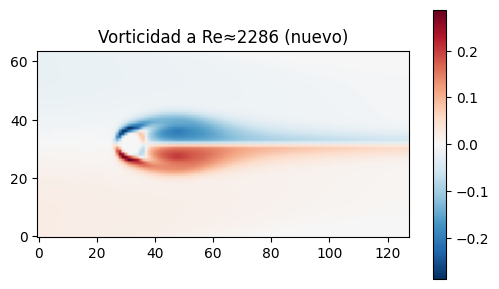

In [ ]:
idx = -1
vorticity_new = np.gradient(snapshots_uy_new[idx], axis=1) - np.gradient(snapshots_ux_new[idx], axis=0)

plt.figure(figsize=(6, 3.5))
plt.imshow(vorticity_new, origin='lower', cmap='RdBu_r')
plt.title(f'Vorticidad a Re≈{Re_new:.0f} (nuevo)')
plt.colorbar()
plt.show()

In [ ]:
DOWNSAMPLE_FACTOR = 4  # mismo factor que en la Fase 1

def downsample(field, factor):
    return field[::factor, ::factor]

low_res_ux_new = np.array([downsample(f, DOWNSAMPLE_FACTOR) for f in snapshots_ux_new])
low_res_uy_new = np.array([downsample(f, DOWNSAMPLE_FACTOR) for f in snapshots_uy_new])

np.save(os.path.join(NEW_DATASET_DIR, 'high_res_ux.npy'), snapshots_ux_new)
np.save(os.path.join(NEW_DATASET_DIR, 'high_res_uy.npy'), snapshots_uy_new)
np.save(os.path.join(NEW_DATASET_DIR, 'low_res_ux.npy'), low_res_ux_new)
np.save(os.path.join(NEW_DATASET_DIR, 'low_res_uy.npy'), low_res_uy_new)
print('Dataset del nuevo Reynolds guardado en:', NEW_DATASET_DIR)

Dataset del nuevo Reynolds guardado en: /content/drive/MyDrive/proyecto_fluidos/dataset_reynolds_generalizacion


## 3. Cargar los modelos ya entrenados (Fase 2 y Fase 3)

Sin reentrenar nada -- usamos los checkpoints tal cual, incluyendo sus estadísticas de normalización originales.

In [ ]:
class SRCNNResidual(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=5, padding=2),
        )

    def forward(self, x_upsampled):
        return x_upsampled + self.net(x_upsampled)

def load_model(filename):
    m = SRCNNResidual(in_channels=2, hidden_channels=32).to(device)
    ckpt = torch.load(os.path.join(MODEL_DIR, filename), map_location=device, weights_only=False)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m, ckpt

mse_only_model, ckpt_mse = load_model('srcnn_cylinder_wake.pt')
physics_model, ckpt_phys = load_model('srcnn_physics_cylinder_wake.pt')

# Estadísticas de normalización -- las del TRAIN del Re ORIGINAL, no las del dataset nuevo
mean_hr, std_hr = ckpt_mse['mean_hr'], ckpt_mse['std_hr']
mean_lr, std_lr = ckpt_mse['mean_lr'], ckpt_mse['std_lr']

print('Modelos cargados. Usando estadísticas de normalización del Re original.')

Modelos cargados. Usando estadísticas de normalización del Re original.


## 4. Preparar el dataset nuevo y evaluar

Todo el dataset nuevo se usa como test -- no hay train/val aquí, porque el punto es evaluar generalización "zero-shot" a un régimen no visto durante el entrenamiento.

In [ ]:
high_res_new = np.stack([snapshots_ux_new, snapshots_uy_new], axis=1).astype(np.float32)
low_res_new  = np.stack([low_res_ux_new,  low_res_uy_new],  axis=1).astype(np.float32)

high_res_new_norm = (high_res_new - mean_hr) / std_hr
low_res_new_norm  = (low_res_new  - mean_lr) / std_lr

high_res_t = torch.from_numpy(high_res_new_norm).float()
low_res_t  = torch.from_numpy(low_res_new_norm).float()
target_hw = high_res_t.shape[-2:]

def relative_l2_error(pred, true):
    return (torch.norm(pred - true) / torch.norm(true)).item()

mean_hr_t = torch.from_numpy(mean_hr[0]).float().to(device)
std_hr_t  = torch.from_numpy(std_hr[0]).float().to(device)

def divergence_loss(pred_norm, dx=1.0, dy=1.0):
    pred_phys = pred_norm * std_hr_t + mean_hr_t
    ux = pred_phys[:, 0, :, :]
    uy = pred_phys[:, 1, :, :]
    dudx = (ux[:, :, 2:] - ux[:, :, :-2]) / (2 * dx)
    dvdy = (uy[:, 2:, :] - uy[:, :-2, :]) / (2 * dy)
    dudx_crop = dudx[:, 1:-1, :]
    dvdy_crop = dvdy[:, :, 1:-1]
    return torch.mean((dudx_crop + dvdy_crop) ** 2)

BATCH_SIZE = 16
l2_mse_new, l2_phys_new = [], []
div_mse_new, div_phys_new = [], []

with torch.no_grad():
    for i in range(0, len(low_res_t), BATCH_SIZE):
        lr_batch = low_res_t[i:i+BATCH_SIZE].to(device)
        hr_batch = high_res_t[i:i+BATCH_SIZE].to(device)
        lr_upsampled = F.interpolate(lr_batch, size=target_hw, mode='bicubic', align_corners=False)

        pred_mse = mse_only_model(lr_upsampled)
        pred_phys = physics_model(lr_upsampled)

        l2_mse_new.append(relative_l2_error(pred_mse, hr_batch))
        l2_phys_new.append(relative_l2_error(pred_phys, hr_batch))
        div_mse_new.append(divergence_loss(pred_mse).item())
        div_phys_new.append(divergence_loss(pred_phys).item())

print(f'=== Evaluación a Re≈{Re_new:.0f} (no visto durante el entrenamiento) ===')
print(f'Error L2 relativo -- MSE-only:  {np.mean(l2_mse_new):.4f}')
print(f'Error L2 relativo -- Física:    {np.mean(l2_phys_new):.4f}')
print(f'Divergencia² -- MSE-only:       {np.mean(div_mse_new):.6f}')
print(f'Divergencia² -- Física:         {np.mean(div_phys_new):.6f}')

=== Evaluación a Re≈2286 (no visto durante el entrenamiento) ===
Error L2 relativo -- MSE-only:  0.0168
Error L2 relativo -- Física:    0.0185
Divergencia² -- MSE-only:       0.000006
Divergencia² -- Física:         0.000006


## 5. Comparación directa: Re original vs. Re nuevo

Completa los valores de la izquierda con los que ya obtuviste en la Fase 3 (los tienes en tu notebook anterior).

In [ ]:
# Completa estos 2 valores con tus resultados de la Fase 3 (celda de comparación cuantitativa)
l2_mse_original = 0.0217   # <-- ajusta si tu número fue distinto
l2_phys_original = 0.0217  # <-- ajusta si tu número fue distinto

print(f'{"Modelo":<20}{"Re original":<15}{"Re nuevo":<15}{"Δ (aumento)"}')
print('-' * 60)
delta_mse = (np.mean(l2_mse_new) - l2_mse_original) / l2_mse_original * 100
delta_phys = (np.mean(l2_phys_new) - l2_phys_original) / l2_phys_original * 100
print(f'{"MSE-only":<20}{l2_mse_original:<15.4f}{np.mean(l2_mse_new):<15.4f}{delta_mse:+.1f}%')
print(f'{"Física":<20}{l2_phys_original:<15.4f}{np.mean(l2_phys_new):<15.4f}{delta_phys:+.1f}%')

Modelo              Re original    Re nuevo       Δ (aumento)
------------------------------------------------------------
MSE-only            0.0217         0.0168         -22.5%
Física              0.0217         0.0185         -14.9%


## 6. Comparación visual

Vorticidad reconstruida a Re original (referencia) vs. Re nuevo, con el modelo MSE-only. Si el modelo generaliza razonablemente, la estructura general del wake debería reconstruirse bien, aunque probablemente con más error en las escalas finas (el Reynolds más alto tiene estructuras más pequeñas y caóticas que el modelo nunca vio).

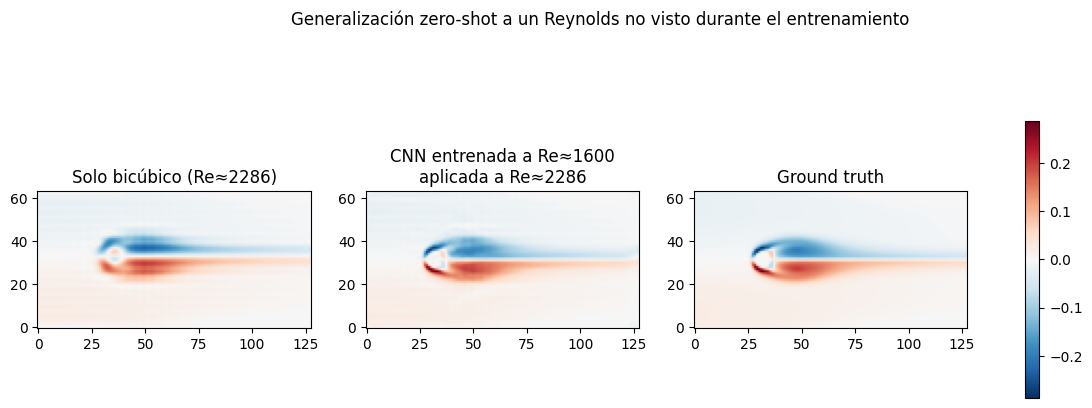

In [ ]:
def compute_vorticity(ux, uy):
    return np.gradient(uy, axis=1) - np.gradient(ux, axis=0)

sample_idx = -1
lr_sample = low_res_t[sample_idx].unsqueeze(0).to(device)
hr_sample = high_res_t[sample_idx]
lr_upsampled = F.interpolate(lr_sample, size=target_hw, mode='bicubic', align_corners=False)

with torch.no_grad():
    pred_sample = mse_only_model(lr_upsampled).cpu().squeeze(0)

def denorm(x):
    return x.numpy() * std_hr[0] + mean_hr[0]

hr_denorm = denorm(hr_sample)
pred_denorm = denorm(pred_sample)
bicubic_denorm = denorm(lr_upsampled.cpu().squeeze(0))

vort_true = compute_vorticity(hr_denorm[0], hr_denorm[1])
vort_pred = compute_vorticity(pred_denorm[0], pred_denorm[1])
vort_bicubic = compute_vorticity(bicubic_denorm[0], bicubic_denorm[1])

vmax = np.abs(vort_true).max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = [f'Solo bicúbico (Re≈{Re_new:.0f})', f'CNN entrenada a Re≈{Re_original:.0f}\naplicada a Re≈{Re_new:.0f}', 'Ground truth']
fields = [vort_bicubic, vort_pred, vort_true]
for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.suptitle('Generalización zero-shot a un Reynolds no visto durante el entrenamiento', y=1.05)
plt.show()

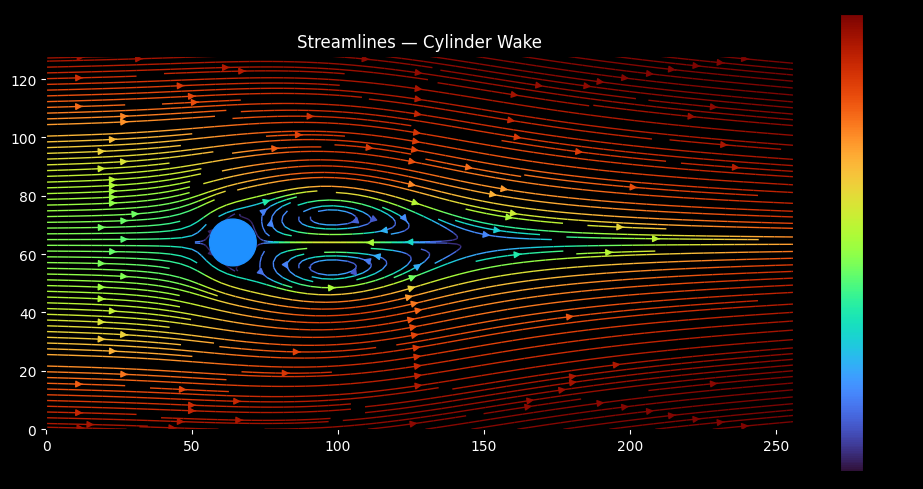

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Ajusta esta ruta a donde tengas guardado el dataset que quieras visualizar
DATASET_DIR = '/content/drive/MyDrive/proyecto_fluidos'  # o .../dataset_reynolds_generalizacion

snapshots_ux = np.load(os.path.join(DATASET_DIR, 'high_res_ux.npy'))
snapshots_uy = np.load(os.path.join(DATASET_DIR, 'high_res_uy.npy'))

idx = -1
ux = snapshots_ux[idx]
uy = snapshots_uy[idx]
speed = np.sqrt(ux**2 + uy**2)

ny, nx = ux.shape
x = np.linspace(0, DOMAIN_X, nx)
y = np.linspace(0, DOMAIN_Y, ny)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

strm = ax.streamplot(X, Y, ux, uy, color=speed, cmap='turbo', density=2.2, linewidth=1)
fig.colorbar(strm.lines, ax=ax, label='Velocidad')

circle = plt.Circle(CYL_CENTER, CYL_RADIUS, color='dodgerblue', zorder=5)
ax.add_patch(circle)

ax.set_xlim(0, DOMAIN_X)
ax.set_ylim(0, DOMAIN_Y)
ax.set_aspect('equal')
ax.set_title('Streamlines — Cylinder Wake', color='white')
ax.tick_params(colors='white')
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig('streamlines_cylinder_wake.png', dpi=150, facecolor='black')
plt.show()